/Users/buttz/miniforge3/envs/py313/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
W0310 20:25:53.189694 2075314 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Sampling: [y]


Output()

([<matplotlib.axis.XTick at 0x3cfc83390>,
 [Text(20, 0, '20'),
  Text(24, 0, '24'),
  Text(28, 0, '28'),
  Text(32, 0, '32'),
  Text(36, 0, '36'),
  Text(40, 0, '40')])

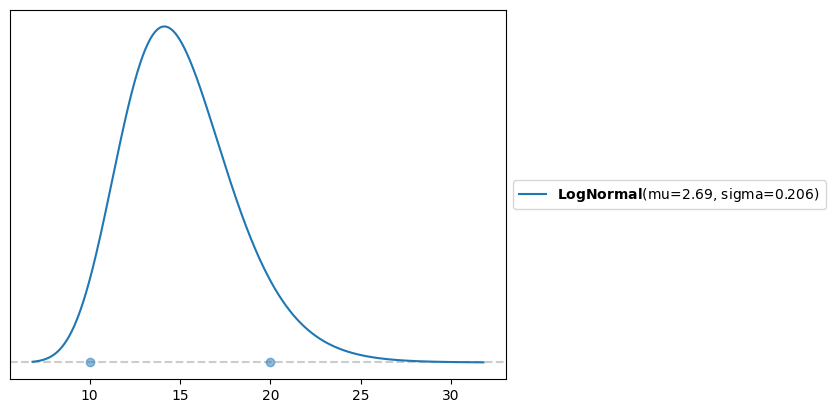

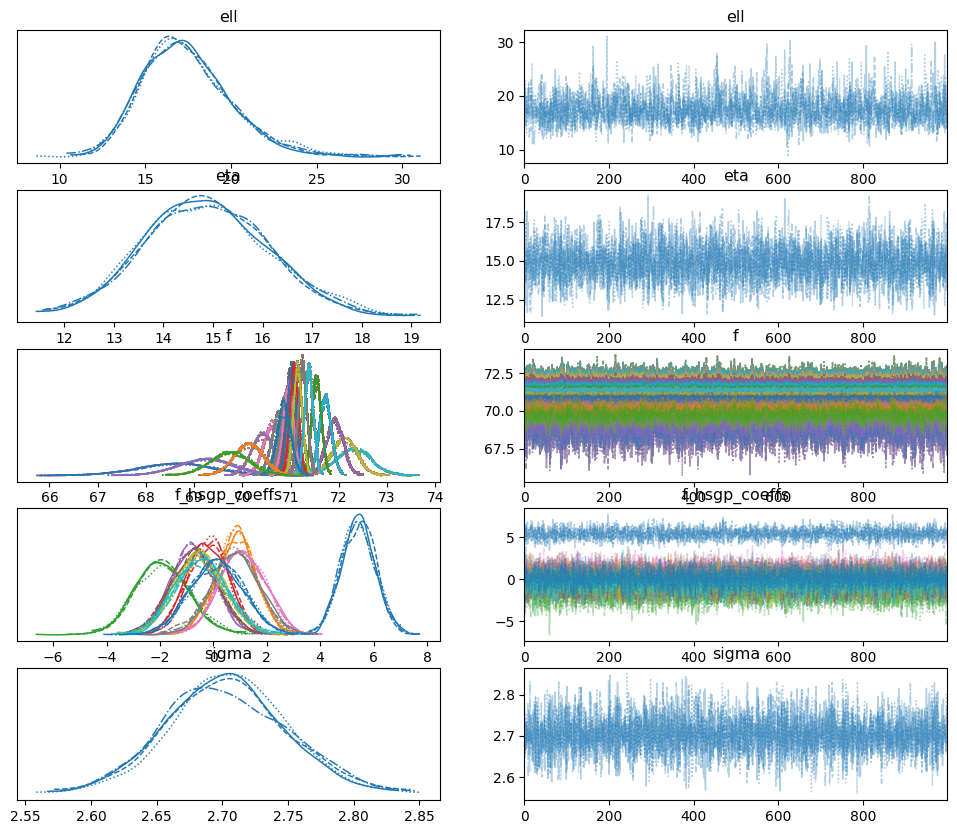

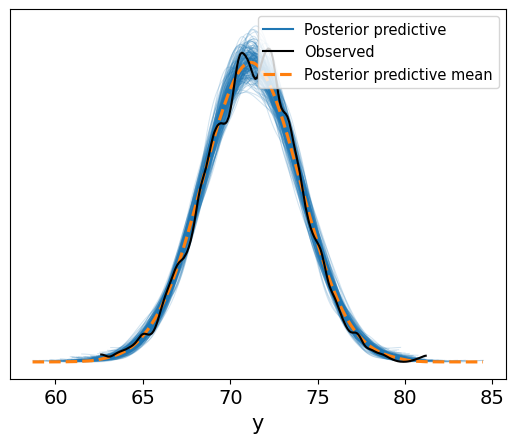

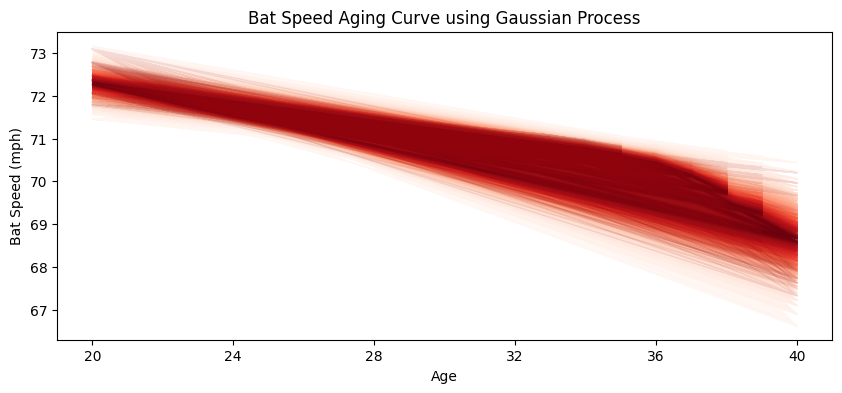

In [1]:
import pandas as pd
import pymc as pm  
import numpy as np
import preliz as pz 
import arviz as az 
import matplotlib.pyplot as plt 
from pymc.gp.util import plot_gp_dist 

# load data 
df = pd.read_csv("bat_speed_df.csv") 

bat_speed = df["avg_swing_speed"].values 
age = df["player_age"].values
min_age = df["min_age"].values
max_age = df["max_age"].values
n_obs = len(bat_speed) 

# creating a prior for the length scale 
# intuitively, aging curves are not very "wiggly"
# so we expected the ell term to be large 
lower, upper = 10, 20 
ell_dist, ax = pz.maxent(pz.LogNormal(), lower=lower, upper=upper, mass=0.9,)

# recommended hyperparams based on x range and length scale prior 
pm.gp.hsgp_approx.approx_hsgp_hyperparams(x_range=[20, 40], lengthscale_range=[10, 20], cov_func="expquad")

# HSGP - Hilbert Spline Gaussian Process 
with pm.Model() as bat_speed_hsgp: 
    ell = ell_dist.to_pymc("ell") 
    eta = pm.HalfNormal("eta", sigma=2.5)  

    cov = eta**2 * pm.gp.cov.ExpQuad(1, ls=ell)  
    gp = pm.gp.HSGP(m=[11], c=7, cov_func=cov) 

    f = gp.prior("f", X=age[:, None])
    sigma = pm.HalfNormal("sigma", sigma=1) 
    y = pm.Normal("y", mu=f, sigma=sigma, observed=bat_speed) 

pm.model_to_graphviz(bat_speed_hsgp) 

with bat_speed_hsgp: 
    hsgp_trace = pm.sample(cores = 4, random_seed = 76, nuts_sampler="numpyro", target_accept=0.95)

# diagonistics 
az.summary(hsgp_trace, var_names=["eta", "ell", "sigma"], round_to=2)
az.plot_trace(hsgp_trace) 

# posterior predictive check 
with bat_speed_hsgp:
    pm.sample_posterior_predictive(hsgp_trace, extend_inferencedata=True, random_seed=76)

az.plot_ppc(hsgp_trace, num_pp_samples=200)  

# extract posterior f 
f_post = az.extract(hsgp_trace, var_names="f").transpose("sample", ...)

# plot aging curve 
fig = plt.figure(figsize=(10, 4))
ax = fig.gca() 
plot_gp_dist(ax, f_post, age) 
plt.title("Bat Speed Aging Curve using Gaussian Process")
plt.xlabel("Age")
plt.ylabel("Bat Speed (mph)")
plt.xticks(np.arange(20, 42, step=4)) 